# Using Neural Networks

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import os
from collections import Counter
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

---
# 1. Download data (Tiny Shakespeare – classic starter dataset)
---

In [2]:
!wget -q https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt -O input.txt

with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read()

print(f"Dataset length: {len(text):,} characters")
print("First 300 chars:\n", text[:300])
print("-" * 60)

Dataset length: 1,115,394 characters
First 300 chars:
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us
------------------------------------------------------------


------------------------------------------------------------
# 2. Character-level (exactly what you already have)
------------------------------------------------------------

In [3]:
chars = sorted(list(set(text)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}
vocab_size_char = len(chars)

print(f"Character vocab size: {vocab_size_char}")
print("Some characters:", chars[:20])

# Encode whole text as character indices
char_data = torch.tensor([char_to_idx[c] for c in text], dtype=torch.long)
print(f"Character sequence length: {len(char_data):,}")

Character vocab size: 65
Some characters: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G']
Character sequence length: 1,115,394


# ------------------------------------------------------------
# 3. Prepare data for MLP training
# ------------------------------------------------------------

In [4]:
def create_dataset(data, seq_length):
    """Create input-output pairs for training the MLP."""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return torch.stack(X), torch.tensor(y)

seq_length = 5  # Length of the input sequence
X, y = create_dataset(char_data, seq_length)
print(f"Dataset created with {X.size(0)} samples.")
print(f"Sample input sequence (indices): {X[-5:-1]}")

Dataset created with 1115389 samples.
Sample input sequence (indices): tensor([[58,  1, 61, 39, 49],
        [ 1, 61, 39, 49, 47],
        [61, 39, 49, 47, 52],
        [39, 49, 47, 52, 45]])


# ------------------------------------------------------------
# 4. Define the MLP model
# ------------------------------------------------------------

In [5]:
class SimpleMLP(nn.Module):
    def __init__(self, input_size, output_size, hidden_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# ------------------------------------------------------------
# 5. Train the MLP model
# ------------------------------------------------------------

In [6]:
def train_model(model, X, y, epochs=10, learning_rate=0.001, batch_size=1024):
    """Train with shuffled mini-batches: many gradient steps per epoch."""
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.CrossEntropyLoss()
    loss_history = []
    n = X.size(0)

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        epoch_loss, steps = 0.0, 0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = X[idx], y[idx]

            # One-hot encode the input and flatten for the MLP
            one_hot_xb = F.one_hot(xb, num_classes=vocab_size_char).float().view(xb.size(0), -1)

            optimizer.zero_grad()
            output = model(one_hot_xb)
            loss = loss_fn(output, yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            steps += 1

        loss_history.append(epoch_loss / steps)
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {epoch_loss / steps:.4f}")

    return loss_history

# ------------------------------------------------------------
# 6. Experiment with different learning rates and model sizes
# ------------------------------------------------------------

torch.Size([1, 65])
Epoch [1/10], Loss: 2.6444
Epoch [2/10], Loss: 2.0682
Epoch [3/10], Loss: 1.9346
Epoch [4/10], Loss: 1.8455
Epoch [5/10], Loss: 1.7844
Epoch [6/10], Loss: 1.7396
Epoch [7/10], Loss: 1.7051
Epoch [8/10], Loss: 1.6774
Epoch [9/10], Loss: 1.6548
Epoch [10/10], Loss: 1.6361


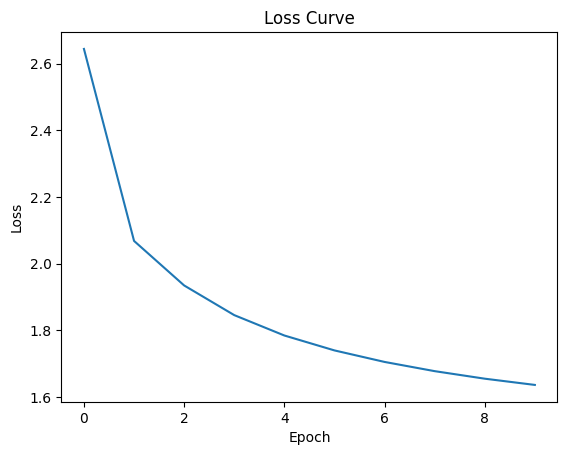

In [9]:
hidden_size = 256  # You can change this to see the effect
model = SimpleMLP(input_size=vocab_size_char * seq_length, output_size=vocab_size_char, hidden_size=256)
print(model(torch.zeros(1, vocab_size_char * seq_length)).shape)

# Train the model
loss_history = train_model(model, X, y, epochs=10, learning_rate=0.001, batch_size=4096)

# Plotting the loss curve
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# ------------------------------------------------------------
# 7. Generate text using the trained MLP
# ------------------------------------------------------------

In [10]:
def generate_text(model, start_str, length=100, temperature=0.8):
    model.eval()

    if any(c not in char_to_idx for c in start_str):
        raise ValueError("start_str contains characters not present in the training data")

    generated = list(start_str)

    # Ensure the model always receives seq_length characters.
    # Pad with '\n' (line starts), not spaces: padded contexts then look
    # like real line beginnings from the training data.
    context = start_str[-seq_length:].rjust(seq_length, '\n')
    input_seq = torch.tensor(
        [[char_to_idx[c] for c in context]],
        dtype=torch.long
    )

    for _ in range(length):
        one_hot_input = F.one_hot(
            input_seq,
            num_classes=vocab_size_char
        ).float().view(1, -1)

        with torch.no_grad():
            output = model(one_hot_input)

        # Sample from the probability distribution instead of taking the
        # argmax: greedy decoding is deterministic, so once a 5-char context
        # repeats, the model falls into an endless loop (e.g. 'the sor the sor').
        # temperature < 1 sharpens the distribution (safer text),
        # temperature > 1 flattens it (more random text).
        probs = F.softmax(output / temperature, dim=1)
        next_char_idx = torch.multinomial(probs, num_samples=1).item()
        generated.append(idx_to_char[next_char_idx])

        input_seq = torch.cat(
            (input_seq[:, 1:], torch.tensor([[next_char_idx]])),
            dim=1
        )

    return "".join(generated)

generated_text = generate_text(model, start_str="A", length=300, temperature=0.8)
print("Generated text:\n", generated_text)

Generated text:
 ANTIGO:
Well it-mind give or't exill genders every lord, God so twazenters her beethere well at, are it me ance befenced of God in this foll! she he
pething all the moits from deatt of hurrait, in the light will shall not comparing sole is, and son,
That thy to if all the eir the ell me reast the nee


# ------------------------------------------------------------
# 8. Subword-level (BPE) comparison
# ------------------------------------------------------------

Byte-level BPE (GPT-2 style) trained on the same corpus: every byte is mapped
to a printable character (so any string round-trips, no `<unk>`), and the
trainer learns merges from single bytes up to subwords/words. The
pre-tokenizer and decoder are set BEFORE training so merges are learned over
the byte representation.

In [ ]:
# Byte-level BPE (GPT-2 style), trained on the same `text` as above
VOCAB_SIZE = 512

bpe_tokenizer = Tokenizer(models.BPE())
bpe_tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
bpe_tokenizer.decoder = decoders.ByteLevel()

bpe_tokenizer.train_from_iterator(
    [text],
    trainers.BpeTrainer(
        vocab_size=VOCAB_SIZE,
        # guarantee all 256 byte-tokens exist before merges start
        initial_alphabet=pre_tokenizers.ByteLevel.alphabet(),
    ),
)

vocab_size_bpe = bpe_tokenizer.get_vocab_size()
bpe_ids = bpe_tokenizer.encode(text).ids

print(f"BPE vocab size: {vocab_size_bpe} (vs {vocab_size_char} characters)")
print(f"BPE sequence length: {len(bpe_ids):,} (vs {len(char_data):,} characters)")
print(f"Compression: {len(text) / len(bpe_ids):.2f} chars/token")
print()
print("Sample subwords of the first sentence:")
print(bpe_tokenizer.encode(text[:100]).tokens)
print()

# round-trip sanity check: decode(encode(x)) must give x back
sample = text[10000:10300]
assert bpe_tokenizer.decode(bpe_tokenizer.encode(sample).ids) == sample
print("Round-trip decode(encode(x)) == x: OK")

In [ ]:
def create_dataset_bpe(data, seq_length):
    """Same sliding-window idea as create_dataset, but over BPE ids."""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return torch.stack(X), torch.tensor(y)

# tokens hold ~2x more text than characters, so use a longer token context
seq_length_bpe = 16  # ~31 characters of context vs 5 characters above
bpe_data = torch.tensor(bpe_ids, dtype=torch.long)
X_bpe, y_bpe = create_dataset_bpe(bpe_data, seq_length_bpe)
print(f"BPE dataset created with {X_bpe.size(0):,} samples (vs {X.size(0):,} character samples).")

# Same MLP, but input/output sized by the BPE vocab: the one-hot input is
# vocab_size_bpe * seq_length_bpe = 512 * 16 = 8192 wide (vs 65 * 5 = 325).
hidden_size_bpe = 512
model_bpe = SimpleMLP(input_size=vocab_size_bpe * seq_length_bpe,
                      output_size=vocab_size_bpe,
                      hidden_size=hidden_size_bpe)
print(model_bpe(torch.zeros(1, vocab_size_bpe * seq_length_bpe)).shape)


def train_model_bpe(model, X, y, epochs=10, learning_rate=0.001, batch_size=4096):
    """Identical to train_model, but one-hots with the BPE vocab size."""
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.CrossEntropyLoss()
    loss_history = []
    n = X.size(0)

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        epoch_loss, steps = 0.0, 0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = X[idx], y[idx]

            one_hot_xb = F.one_hot(xb, num_classes=vocab_size_bpe).float().view(xb.size(0), -1)

            optimizer.zero_grad()
            output = model(one_hot_xb)
            loss = loss_fn(output, yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            steps += 1

        loss_history.append(epoch_loss / steps)
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {epoch_loss / steps:.4f}")

    return loss_history


loss_history_bpe = train_model_bpe(model_bpe, X_bpe, y_bpe, epochs=10, learning_rate=0.001, batch_size=4096)

# Overlay both loss curves. NOTE: losses are NOT directly comparable (65-way
# vs 512-way cross-entropy); this just shows training dynamics side by side.
import matplotlib.pyplot as plt

plt.figure()
plt.plot(loss_history, label=f"character-level (vocab {vocab_size_char})")
plt.plot(loss_history_bpe, label=f"subword BPE (vocab {vocab_size_bpe})")
plt.title("Loss Curve: character vs. subword")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# Byte-level BPE stores '\n' as its byte-mapped character in the vocab, so look
# it up by encoding the newline string itself (always a single-byte token).
newline_id = bpe_tokenizer.encode("\n").ids[0]


def generate_text_bpe(model, start_str, length=100, temperature=0.8):
    model.eval()

    if len(start_str) == 0:
        raise ValueError("start_str must not be empty")

    # With byte-level BPE every string encodes to some token id, so there is
    # no <unk> case to validate against.
    generated = bpe_tokenizer.encode(start_str).ids

    # Ensure the model always receives seq_length_bpe tokens. Pad with the
    # newline token (line starts), not spaces: padded contexts then look like
    # real line beginnings from the training data.
    context = generated[-seq_length_bpe:]
    context = [newline_id] * (seq_length_bpe - len(context)) + context
    input_seq = torch.tensor([context], dtype=torch.long)

    for _ in range(length):
        one_hot_input = F.one_hot(
            input_seq,
            num_classes=vocab_size_bpe
        ).float().view(1, -1)

        with torch.no_grad():
            output = model(one_hot_input)

        # Sample (not argmax) so a repeated context cannot lock the model
        # into an endless loop; temperature < 1 sharpens the distribution.
        probs = F.softmax(output / temperature, dim=1)
        next_token_id = torch.multinomial(probs, num_samples=1).item()
        generated.append(next_token_id)

        input_seq = torch.cat(
            (input_seq[:, 1:], torch.tensor([[next_token_id]])),
            dim=1
        )

    # ByteLevel decoder reverses the byte mapping exactly: decode(ids) == text
    return bpe_tokenizer.decode(generated)


generated_text_bpe = generate_text_bpe(model_bpe, start_str="First Citizen:", length=300, temperature=0.8)
print("Generated text (subword BPE):\n", generated_text_bpe)

# ------------------------------------------------------------
# 9. Character vs. subword: what to compare
# ------------------------------------------------------------

- **Vocab**: 65 fixed characters vs 512 learned subwords.
- **Sequence length**: 1,115,394 character steps vs ~575,000 BPE steps
  (~1.9 chars/token) - the same corpus is ~2x shorter in tokens.
- **Context**: 5 characters vs 16 tokens (~31 characters) - the BPE model
  sees a longer span of text per prediction.
- **Samples**: the BPE dataset has ~2x fewer samples for the same corpus,
  but each one covers more text.
- **Loss values are not comparable** across the two (65-way vs 512-way
  cross-entropy). Judge the *generated text* instead: with the same tiny
  MLP, BPE generation should look more word-like (frequent chunks such as
  ` the`, `ing`, `er` become single tokens), while character-level
  generation shows more local character patterns.